#**ML Assignment 4**

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid')

##  Load Dataset

In [2]:
# Download latest version from Kaggle

import kagglehub

path = kagglehub.dataset_download("hopesb/student-depression-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-depression-dataset' dataset.
Path to dataset files: /kaggle/input/student-depression-dataset


In [3]:
# Load dataset
import os

file_path = os.path.join(path, "Student Depression Dataset.csv")

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


#Task 1: Identify data quality issues in the dataset

###2.1 Check Data Types

In [4]:
df.dtypes

,0
id,int64
Gender,object
Age,float64
City,object
Profession,object
Academic Pressure,float64
Work Pressure,float64
CGPA,float64
Study Satisfaction,float64
Job Satisfaction,float64


In [5]:
df["Sleep Duration"].unique()

array(['5-6 hours', 'Less than 5 hours', '7-8 hours', 'More than 8 hours',
       'Others'], dtype=object)

In [6]:
sleep_map = {
    'Less than 5': 4,
    '5-6 hours': 5.5,
    '7-8 hours': 7.5,
    'More than 8': 9
}

df["Sleep Duration"] = df["Sleep Duration"].map(sleep_map)

In [7]:
df["Have you ever had suicidal thoughts ?"].unique()

array(['Yes', 'No'], dtype=object)

In [8]:
df["Have you ever had suicidal thoughts ?"] = df["Have you ever had suicidal thoughts ?"].map({
    "Yes": 1,
    "No": 0
})

In [9]:
categorical_cols = ["Gender", "City", "Profession", "Dietary Habits", "Degree", "Family History of Mental Illness"]

df[categorical_cols] = df[categorical_cols].astype("category")

In [10]:
df.dtypes

,0
id,int64
Gender,category
Age,float64
City,category
Profession,category
Academic Pressure,float64
Work Pressure,float64
CGPA,float64
Study Satisfaction,float64
Job Satisfaction,float64


Some columns were stored as object data types despite representing numerical or binary values.
For example, Sleep Duration was stored as text and converted into numeric values using mapping.
Also, suicidal thoughts was converted from categorical (Yes/No) into binary (0/1).
These corrections ensure proper numerical analysis and improve model performance.

#Task 2: Apply one missing value strategy and explain why

In [11]:
df.isna().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


In [12]:
df["Sleep Duration"].fillna(df["Sleep Duration"].mode()[0], inplace=True)

/tmp/ipykernel_5358/3476402715.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Sleep Duration"].fillna(df["Sleep Duration"].mode()[0], inplace=True)


In [13]:
df["Financial Stress"].fillna(df["Financial Stress"].median(), inplace=True)

/tmp/ipykernel_5358/2715629711.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Financial Stress"].fillna(df["Financial Stress"].median(), inplace=True)


In [14]:
df.isna().sum()

,0
id,0
Gender,0
Age,0
City,0
Profession,0
Academic Pressure,0
Work Pressure,0
CGPA,0
Study Satisfaction,0
Job Satisfaction,0


The dataset contains missing values in two columns: Sleep Duration and Financial Stress.

For Sleep Duration, a large number of values were missing, so mode imputation was applied since it is a categorical variable and mode preserves the most frequent category.

For Financial Stress, only a small number of values were missing, so median imputation was used because it is robust to outliers and suitable for numerical data.

These strategies ensure minimal data loss and maintain the integrity of the dataset.

# Task 3: Detect and handle outliers using IQR

In [15]:
num_cols = [
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

In [16]:
outliers_dict = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outliers_dict[col] = len(outliers)

print(outliers_dict)

{'Age': 12, 'Academic Pressure': 0, 'Work Pressure': 3, 'CGPA': 9, 'Study Satisfaction': 0, 'Job Satisfaction': 8, 'Work/Study Hours': 0, 'Financial Stress': 0}


In [17]:
df_capped = df.copy()

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower, upper)

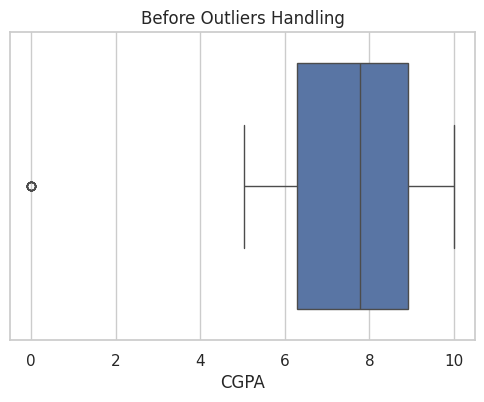

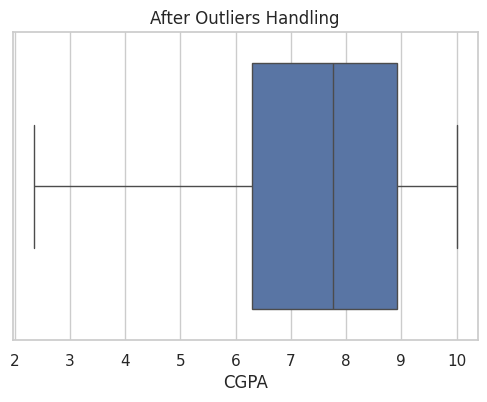

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x=df["CGPA"])
plt.title("Before Outliers Handling")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df_capped["CGPA"])
plt.title("After Outliers Handling")
plt.show()

Outliers were detected using the Interquartile Range (IQR) method for numerical features.

The results showed that some columns contained outliers, such as Age (12 outliers), CGPA (9 outliers), Job Satisfaction (8 outliers), and Work Pressure (3 outliers), while other columns like Academic Pressure and Study Satisfaction did not contain outliers.

To handle these outliers, the capping (clipping) method was applied, where values outside the acceptable range
were replaced with the nearest boundary values.

As shown in the boxplot of CGPA, extreme values were successfully reduced after applying capping, resulting in a more balanced distribution without removing any data points.

This approach was chosen because it preserves the dataset size while minimizing the impact of extreme values, which may represent valid observations rather than errors.

# Task 4: Normalize numerical features using both Min-Max and Z-score

In [19]:
num_cols = [
    "Age",
    "Academic Pressure",
    "Work Pressure",
    "CGPA",
    "Study Satisfaction",
    "Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress"
]

###**Min-Max Normalization**

In [20]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_minmax = df.copy()
df_minmax[num_cols] = scaler.fit_transform(df_minmax[num_cols])

df_minmax[num_cols].head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
0,0.365854,1.0,0.0,0.897,0.4,0.0,0.250000,0.00
1,0.146341,0.4,0.0,0.590,1.0,0.0,0.250000,0.25
2,0.317073,0.6,0.0,0.703,1.0,0.0,0.750000,0.00
3,0.243902,0.6,0.0,0.559,0.4,0.0,0.333333,1.00
4,0.170732,0.8,0.0,0.813,0.6,0.0,0.083333,0.00


###**Z-score Normalization**

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_zscore = df.copy()
df_zscore[num_cols] = scaler.fit_transform(df_zscore[num_cols])

df_zscore[num_cols].head()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
0,1.463165,1.345543,-0.009777,0.893393,-0.693425,-0.01534,-1.121213,-1.488857
1,-0.371474,-0.826104,-0.009777,-1.194076,1.510636,-0.01534,-1.121213,-0.793081
2,1.055467,-0.102222,-0.009777,-0.425724,1.510636,-0.01534,0.497095,-1.488857
3,0.443921,-0.102222,-0.009777,-1.404862,-0.693425,-0.01534,-0.851495,1.294246
4,-0.167625,0.621660,-0.009777,0.322229,0.041262,-0.01534,-1.660650,-1.488857


Numerical features such as Age, CGPA, Academic Pressure, Work Pressure, and Financial Stress were normalized using both Min-Max and Z-score normalization techniques.

Min-Max normalization scaled the values to a range between 0 and 1, ensuring that all features contribute equally without being influenced by their original scale.

Z-score normalization standardized the data by centering it around a mean of 0 and a standard deviation of 1, allowing features to be compared on the same scale.


# Task 5: Apply PCA only if the numerical features show a correlation

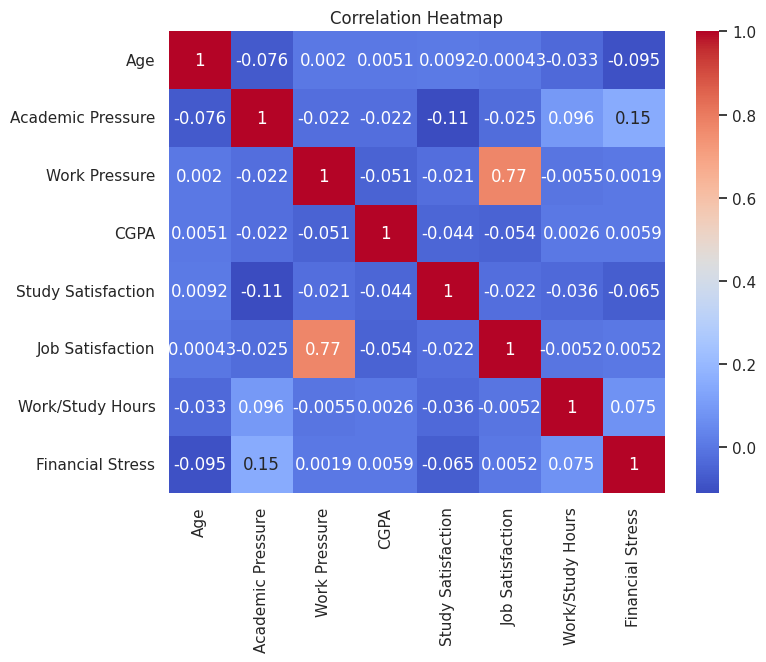

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

A correlation analysis was performed on the numerical features before applying PCA.
The results showed that most features have weak correlations (values close to 0), indicating that they do not have strong linear relationships.

However, a strong positive correlation was observed between Work Pressure and Job Satisfaction (≈ 0.77), suggesting some overlapping information between these two features.

Since PCA is most effective when multiple features are strongly correlated, the overall benefit of applying PCA to this dataset is limited.

Therefore, PCA is not strictly necessary